## Figure 6. The prevailing storm direction for the top 400 in each domain of the contiguous United States. 

In [4]:
#Packages:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import sys
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon
import cartopy.crs as ccrs



In [5]:
from pathlib import Path

# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

# Import storm dataset and related modules
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_direction import mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length, mean_velocity, mean_direction, mean_direction_ln, mean_direction_weighted
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, plot_storm_track, plot_storm_time_steps

In [6]:
# import plottig functions
from pathlib import Path
import sys
# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.diagnostic_plots import circular_percentile, circular_mean, circular_trend, circular_trend_permutation_test

In [7]:
# ── 1) LOAD GRID ─────────────────────────────────────────────────────────────
shp_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/CONUS_5d_grid.shp"
grid = gpd.read_file(shp_path)

# Make sure we’re in geographic coordinates for Cartopy plotting
grid = grid.to_crs(epsg=4326)

In [8]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
storm_stats = os.listdir(f)
storm_stats = [file for file in storm_stats if file.endswith('.csv')]

centroids = grid.geometry.centroid
xs = centroids.x.values
ys = centroids.y.values

domains = pd.DataFrame(index=grid['D_name'], columns=["x", "y"])
domains["x"] = xs
domains["y"] = ys

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_58388/4044105814.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.geometry.centroid


In [9]:
storm_stats

['storm_properties_A9.csv',
 'storm_properties_C1.csv',
 'storm_properties_B5.csv',
 'storm_properties_B4.csv',
 'storm_properties_A8.csv',
 'storm_properties_13.0.csv',
 'storm_properties_B6.csv',
 'storm_properties_C2.csv',
 'storm_properties_69.0.csv',
 'storm_properties_94.0.csv',
 'storm_properties_C3.csv',
 'storm_properties_B7.csv',
 'storm_properties_49.0.csv',
 'storm_properties_B3.csv',
 'storm_properties_C7.csv',
 'storm_properties_A10.csv',
 'storm_properties_31.0.csv',
 'storm_properties_50.0.csv',
 'storm_properties_15.0.csv',
 'storm_properties_A11.csv',
 'storm_properties_C6.csv',
 'storm_properties_B2.csv',
 'storm_properties_C4.csv',
 'storm_properties_52.0.csv',
 'storm_properties_76.0.csv',
 'storm_properties_102..csv',
 'storm_properties_33.0.csv',
 'storm_properties_C10.csv',
 'storm_properties_A12.csv',
 'storm_properties_B1.csv',
 'storm_properties_C5.csv',
 'storm_properties_68.0.csv',
 'storm_properties_D6.csv',
 'storm_properties_D7.csv',
 'storm_properties_D

In [10]:
## function for domain stats
def _month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Fall'


def _compute_variable_stats(df_subset, key, perform_direction_trend=False):
    row = {}

    if key == 'dir':
        directions = df_subset['storm_direction'].dropna()
        if directions.empty:
            return row

        row['mean'] = circular_mean(directions, rayleigh_test=True)[0]
        row['median'] = circular_percentile(directions, 50)
        row['p75'] = circular_percentile(directions, 75)
        row['p25'] = circular_percentile(directions, 25)
        row['p5'] = circular_percentile(directions, 5)
        row['p95'] = circular_percentile(directions, 95)
        row['max'] = directions.max()
        row['min'] = directions.min()
        row['p_value'] = circular_mean(directions, rayleigh_test=True)[1]  # p-value for non-uniformity

        if perform_direction_trend:
            df_year = df_subset.resample('YE').apply(lambda x: x.loc[x['mean_intensity'].idxmax()])
            x = np.arange(len(df_year))
            if len(df_year) > 1 and df_year['storm_direction'].nunique() > 1:
                results = circular_trend_permutation_test(x, df_year['storm_direction'], n_permutations=10000)
                row['trend'] = results['rate_direction_deg']
                row['p_value'] = results['p_value']
            else:
                row['trend'] = np.nan
                row['p_value'] = np.nan

    elif key == 'speed':
        values = df_subset['storm_velocity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'intensity':
        values = df_subset['mean_intensity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'area':
        values = df_subset['area'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'angular_var':
        values = df_subset['angular_variance_weighted'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)

    return row


def compute_stats_by_season(df, key, perform_direction_trend=False):
    season_groups = {'ALL': df}
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        season_groups[season] = df[df['season'] == season]

    seasonal_stats = {}
    for season_name, season_df in season_groups.items():
        seasonal_stats[season_name] = _compute_variable_stats(
            season_df,
            key,
            perform_direction_trend=(perform_direction_trend and season_name == 'ALL'),
        )
    return seasonal_stats


def domain_stats_func(top_storms, perform_direction_trend=False, angular_variance_threshold=None, event_type=None):
    variable_keys = ['dir', 'speed', 'intensity', 'area', 'angular_var']
    season_keys = ['ALL', 'Winter', 'Spring', 'Summer', 'Fall']
    stats = {key: {season: pd.DataFrame() for season in season_keys} for key in variable_keys}

    for cat in grid['D_name']:
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(f + '/' + cat_file)
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        df = df[df['id'] > (400 - top_storms)].copy()

        # get the date from the domain name
        df.index = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
        df.drop(columns=['storm_event'], inplace=True)
        df = df.sort_values(by=df.index.name)
        df['season'] = df.index.month.map(_month_to_season)

        if angular_variance_threshold is not None:
            if event_type == 'linear':
                df = df[df['angular_variance'] < angular_variance_threshold].copy()
            elif event_type == 'nonlinear':
                df = df[df['angular_variance_weighted'] > angular_variance_threshold].copy()

        domain_x = domains.loc[cat]['x']
        domain_y = domains.loc[cat]['y']

        for key in variable_keys:
            seasonal_stats = compute_stats_by_season(
                df,
                key,
                perform_direction_trend=perform_direction_trend,
            )

            for season_name, values in seasonal_stats.items():
                for stat_name, stat_value in values.items():
                    stats[key][season_name].loc[cat, stat_name] = stat_value
                stats[key][season_name].loc[cat, 'centroid_x'] = domain_x
                stats[key][season_name].loc[cat, 'centroid_y'] = domain_y

    for key in variable_keys:
        for season_name in season_keys:
            stats[key][season_name].reset_index(inplace=True)
            stats[key][season_name].rename(columns={'index': 'Domain'}, inplace=True)

    return stats

In [11]:
# Define the function, where it is plotted using the CONUS as a basemap
def plot_directional_arrow_with_fan(x_center, y_center, direction_percentiles, magnitude, ax, main_direction=None):
    """
    Plot a directional arrow with two percentile fans.

    Parameters:
    - x_center, y_center: Center coordinates for the arrow
    - direction_percentiles: Iterable [p5, p25, p50, p75, p95] in degrees
    - magnitude: Length of the arrow in degrees
    - ax: Matplotlib axis with PlateCarree projection
    - main_direction: Optional mean direction in degrees (defaults to p50)
    """
    direction_percentiles = np.asarray(direction_percentiles, dtype=float)
    if direction_percentiles.shape[0] != 5:
        raise ValueError("direction_percentiles must have five values [5, 25, 50, 75, 95].")

    # Unwrap around the median (50th percentile) so spreads straddle 0/360 correctly
    median_dir = direction_percentiles[2]
    centered = (direction_percentiles - median_dir + 180) % 360 - 180 + median_dir
    p5, p25, p50, p75, p95 = centered

    main_dir = main_direction if main_direction is not None else p50

    # Convert angles from degrees to radians
    main_angle_rad = np.radians(main_dir)
    median_angle_rad = np.radians(p50)

    # Calculate arrow endpoints
    arrow_end_x = x_center + magnitude * np.cos(main_angle_rad)
    arrow_end_y = y_center + magnitude * np.sin(main_angle_rad)

    median_end_x = x_center + magnitude * np.cos(median_angle_rad)
    median_end_y = y_center + magnitude * np.sin(median_angle_rad)

    def _add_fan(angle_low, angle_high, color, alpha):
        start = min(angle_low, angle_high)
        end = max(angle_low, angle_high)
        arc_angles = np.linspace(start, end, 80)
        arc_x = x_center + magnitude * np.cos(np.radians(arc_angles))
        arc_y = y_center + magnitude * np.sin(np.radians(arc_angles))

        fan_vertices = [(x_center, y_center)]
        fan_vertices.append((x_center + magnitude * np.cos(np.radians(angle_low)),
                             y_center + magnitude * np.sin(np.radians(angle_low))))
        fan_vertices.extend(zip(arc_x, arc_y))
        fan_vertices.append((x_center + magnitude * np.cos(np.radians(angle_high)),
                             y_center + magnitude * np.sin(np.radians(angle_high))))
        fan_vertices.append((x_center, y_center))

        fan = Polygon(fan_vertices, alpha=alpha, color=color, transform=ccrs.PlateCarree())
        ax.add_patch(fan)
        ax.plot([x_center, fan_vertices[1][0]], [y_center, fan_vertices[1][1]],
                color=color, linestyle='--', linewidth=1.2, alpha=0.9, transform=ccrs.PlateCarree())
        ax.plot([x_center, fan_vertices[-2][0]], [y_center, fan_vertices[-2][1]],
                color=color, linestyle='--', linewidth=1.2, alpha=0.9, transform=ccrs.PlateCarree())
        ax.plot(arc_x, arc_y, color=color, linestyle='-', linewidth=1.2, alpha=0.9, transform=ccrs.PlateCarree())

    # Outer (5–95) and inner (25–75) fans
    _add_fan(p5, p95, color='skyblue', alpha=0.5)
    _add_fan(p25, p75, color='royalblue', alpha=0.5)

    # Plot the main and median arrows
    ax.annotate('', xy=(arrow_end_x, arrow_end_y), xytext=(x_center, y_center),
                arrowprops=dict(arrowstyle='->', color='red', lw=3),
                transform=ccrs.PlateCarree())

    ax.annotate('', xy=(median_end_x, median_end_y), xytext=(x_center, y_center),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5),
                transform=ccrs.PlateCarree())

    # Add center point
    ax.plot(x_center, y_center, 'ko', markersize=8, transform=ccrs.PlateCarree())



In [15]:
domain_stats_all = domain_stats_func(top_storms, perform_direction_trend=False, angular_variance_threshold=0.51, event_type='nonlinear')
domain_stats = domain_stats_all['dir']['ALL']

In [16]:
domain_stats

,Domain,mean,median,p75,p25,p5,p95,max,min,p_value,centroid_x,centroid_y
0,B6,9.188916,6.262837,59.036175,322.302480,229.661003,131.757533,173.916114,-173.877871,1.106745e-08,-97.437126,41.888331
1,E6,334.592901,333.014600,27.538846,263.742316,174.002177,100.480446,178.736946,-169.642530,2.240291e-04,-97.437126,26.888331
2,B7,357.300110,353.663344,38.892703,304.885381,216.295558,92.374466,179.677230,-172.592452,1.572872e-14,-92.437126,41.888331
3,C7,350.142711,348.244111,34.790928,302.086879,239.319192,110.418557,179.741604,-172.001847,2.311304e-16,-92.437126,36.888331
4,A7,20.447904,23.686809,63.489300,333.680435,269.299498,142.597867,149.514239,-179.599847,2.969808e-14,-92.437126,46.888331
5,D7,351.573685,346.292837,39.583198,310.078938,216.946149,126.357579,156.256074,-179.779488,3.244697e-10,-92.437126,31.888331
6,A12,46.021613,48.346298,94.028529,347.019960,291.224334,127.275612,171.589380,-174.358473,1.699505e-22,-67.437126,46.888331
7,C4,1.534944,1.437914,52.977953,309.549542,214.708403,140.020890,179.533434,-177.563272,3.730757e-12,-107.437126,36.888331
8,D4,10.130124,9.846528,62.444093,317.028844,232.802247,150.423658,178.931527,-176.238717,1.304578e-10,-107.437126,31.888331
9,A5,37.401566,33.448208,75.911005,353.834577,275.391387,139.193916,165.030935,-156.807991,5.550516e-13,-102.437126,46.888331


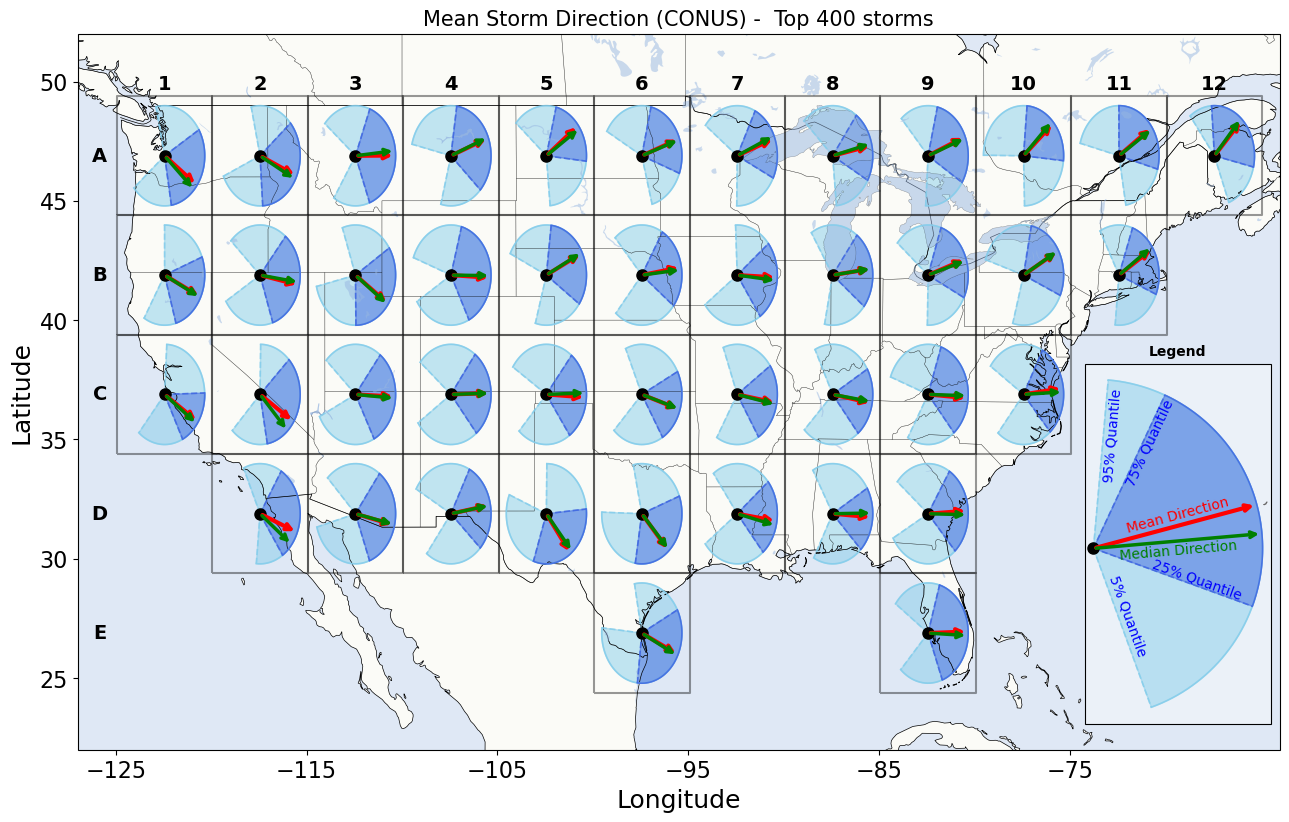

In [17]:
## conus direction plot
# ── 2) Setup plot ─────────────────────────
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 9))
ax = plt.axes(projection=proj)

ax.set_extent([-127, -64, 22, 52], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
ax.add_feature(cfeature.LAND, alpha=0.2)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.OCEAN, alpha=0.3)

# Optional: grid outline
grid.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), linewidth=1.5, alpha=0.4, color='black')


# ── 4) plot_directional_arrow_with_fan
top_storms = 400
domain_stats_all = domain_stats_func(top_storms, perform_direction_trend=False, angular_variance_threshold=0.51, event_type='nonlinear')
domain_stats = domain_stats_all['dir']['ALL']
for dom in domain_stats.itertuples():
    plot_directional_arrow_with_fan(
        x_center=dom.centroid_x,
        y_center=dom.centroid_y,
        direction_percentiles=[dom.p5, dom.p25, dom.median, dom.p75, dom.p95],
        magnitude=2.1,  # adjust as needed
        ax=ax,
        main_direction=dom.mean,
    )

# add axis ticks
ax.set_xticks(np.arange(-125, -65, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(25, 55, 5), crs=ccrs.PlateCarree())
ax.tick_params(axis='both', which='major', labelsize=16)
## add axis labels
ax.set_xlabel('Longitude', fontsize=18)
ax.set_ylabel('Latitude', fontsize=18)
plt.title(f"Mean Storm Direction (CONUS) -  Top {top_storms} storms", fontsize=15)
plt.tight_layout()

#  -5) add subplot for explainin arrows and fan
# Create an inset axes for the legend

inset_ax = plt.axes([0.81, 0.14, 0.2, 0.4], projection=ccrs.PlateCarree())
# Set limits for the inset axes
#inset_ax.set_xlim(-10, 10)
#inset_ax.set_ylim(-10, 10)
# Hide the axes


inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_xticklabels([])
inset_ax.set_yticklabels([])
inset_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

inset_ax.set_facecolor((1, 1, 1, 0.4))  # almost transparent background for better visibility if overlaid
# Plot an example arrow with fan in the inset axes

plot_directional_arrow_with_fan(
    x_center=0,
    y_center=0,
    direction_percentiles=[-70, -20, 5, 65, 85],
    magnitude=8,
    ax=inset_ax,
    main_direction=15,
)
inset_ax.set_title('Legend', fontsize=10, fontweight='bold')
# Add text annotations to explain the elements
inset_ax.text(0.5, 0.58, 'Mean Direction', color='red', fontsize=10, ha='center', va='center',rotation=15, transform=inset_ax.transAxes)
inset_ax.text(0.5, 0.48, 'Median Direction', color='green', fontsize=10, ha='center', va='center',transform=inset_ax.transAxes,rotation=5)
inset_ax.text(0.15, 0.8, '95% Quantile', color='blue', fontsize=10, ha='center', va='center',transform=inset_ax.transAxes,rotation=85)
inset_ax.text(0.6, 0.4, '25% Quantile', color='blue', fontsize=10, ha='center', va='center',transform=inset_ax.transAxes,rotation=-20)
inset_ax.text(0.35, 0.78, '75% Quantile', color='blue', fontsize=10, ha='center', va='center',transform=inset_ax.transAxes,rotation=65)
inset_ax.text(0.23, 0.3, '5% Quantile', color='blue', fontsize=10, ha='center', va='center',transform=inset_ax.transAxes,rotation=-70)

#put  labels on top of the grid from 1 to 12
for i in range(1, 13):
    cell = grid[(grid['row_index']==2.0) & (grid['col_index']==float(i-1))]
    x = (cell.right.values[0] + cell.left.values[0]) / 2  
    y = cell.top.values[0] + 0.5
    ax.text(x, y, str(i), fontsize=14, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())

for i, letter in enumerate(['A', 'B', 'C', 'D', 'E']):
        if i < 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==0.0)]
            
        elif i == 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==1.0)]
        else:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==5.0)]
        x = grid.loc[26].left - 0.9
        y = (cell.top.values[0] + cell.bottom.values[0]) / 2
        ax.text(x, y, letter, fontsize = 14 , fontweight='bold',ha='center', va='center', transform=ccrs.PlateCarree())


plt.show()

In [13]:
domain_stats = domain_stats_all['dir']['ALL']

NameError: name 'domain_stats_all' is not defined

In [ ]:
domain_stats_all['angular_var']['ALL']

,Domain,mean,median,p75,p25,centroid_x,centroid_y
0,B6,0.261308,0.257676,0.387519,0.149811,-97.437126,41.888331
1,E6,0.246544,0.248151,0.376307,0.113417,-97.437126,26.888331
2,B7,0.271999,0.273558,0.392839,0.171707,-92.437126,41.888331
3,C7,0.279039,0.277818,0.379164,0.184036,-92.437126,36.888331
4,A7,0.254854,0.257288,0.368661,0.142807,-92.437126,46.888331
5,D7,0.275978,0.291075,0.374438,0.170216,-92.437126,31.888331
6,A12,0.289352,0.304924,0.398775,0.170879,-67.437126,46.888331
7,C4,0.308508,0.326163,0.418964,0.199105,-107.437126,36.888331
8,D4,0.285339,0.305111,0.420875,0.145568,-107.437126,31.888331
9,A5,0.250593,0.250216,0.371652,0.130765,-102.437126,46.888331
